In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset and display:

First 5 rows  
Shape  
Column types  

In [2]:
df = pd.read_csv(r"F:\Data_Analytics\m3w1s3_grocery_store_data.csv")
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [3]:
df.shape

(25000, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         25000 non-null  int64  
 1   Store_ID            25000 non-null  object 
 2   Transaction_Amount  25000 non-null  float64
 3   Basket_Size         25000 non-null  int64  
 4   Visit_Day           25000 non-null  object 
 5   Customer_Age        25000 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.1+ MB


Check:

Missing values  
Unique values in Store_ID and Visit_Day  

In [5]:
df.isnull().sum()

Customer_ID           0
Store_ID              0
Transaction_Amount    0
Basket_Size           0
Visit_Day             0
Customer_Age          0
dtype: int64

In [6]:
df['Visit_Day'].unique()

array(['Thu', 'Fri', 'Sun', 'Tue', 'Wed', 'Sat', 'Mon'], dtype=object)

In [7]:
df['Store_ID'].unique()

array(['S001', 'S004', 'S002', 'S003'], dtype=object)

Find the mean Transaction Amount

In [8]:
print(df['Transaction_Amount'].mean())

75.02023080000001


Find mean Transaction Amount:

Per Store_ID   
Per Visit_Day  

In [9]:
Avg_Transaction_Amount = df.groupby('Store_ID')['Transaction_Amount'].mean().reset_index().rename(columns = {'Transaction_Amount' : 'Avg_Transaction_Amount'})
Avg_Transaction_Amount

,Store_ID,Avg_Transaction_Amount
0,S001,75.191684
1,S002,75.257383
2,S003,74.627236
3,S004,75.003663


In [10]:
df.groupby('Visit_Day')['Transaction_Amount'].mean().reset_index().rename(columns = {'Transaction_Amount' : 'Avg_Transaction_Amount'})

,Visit_Day,Avg_Transaction_Amount
0,Fri,74.905804
1,Mon,74.847254
2,Sat,75.678271
3,Sun,74.391620
4,Thu,75.115612
5,Tue,75.220323
6,Wed,74.980282


Which store has the highest average transaction value?

In [11]:
Avg_Transaction_Amount.sort_values(by = 'Avg_Transaction_Amount', ascending=False).head(1)

,Store_ID,Avg_Transaction_Amount
1,S002,75.257383


If one transaction = ₹1,00,000 is added:  

What happens to mean?

In [12]:
new_row = {'Customer_ID' : 98765,
          'Store_ID' : 'S004',
          'Transaction_Amount' : 100000,
          'Basket_Size' : 5,
          'Visit_Day' : 'Sun',
          'Customer_Age' : 35}

In [15]:
df_new = pd.DataFrame([new_row])

In [16]:
df_new = pd.concat([df, df_new])

In [17]:
df_new.tail(1)

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,98765,S004,100000.0,5,Sun,35


In [18]:
print(df_new['Transaction_Amount'].mean())

79.01707011719532


In [19]:
print(df_new['Transaction_Amount'].mean() - df['Transaction_Amount'].mean())

3.9968393171953096


Find median Transaction Amount

In [20]:
print(df['Transaction_Amount'].median())
print(df['Transaction_Amount'].mean())

75.06
75.02023080000001


Compare:

Mean vs Median of Transaction Amount
What does the difference indicate?

**Mean and Median are almost the same. So the dataset is very much reliable.**

Find median Basket_Size per Store_ID

In [21]:
df.groupby('Store_ID' ) ['Basket_Size' ].median()

Store_ID
S001    5.0
S002    5.0
S003    5.0
S004    5.0
Name: Basket_Size, dtype: float64

Find:

Most common Visit_Day
Most common Basket_Size

In [22]:
df['Visit_Day'].mode()

0    Mon
Name: Visit_Day, dtype: object

In [23]:
df['Basket_Size'].mode()

0    4
Name: Basket_Size, dtype: int64

Find mode of Store_ID → Which store gets most visits?

In [24]:
df['Store_ID'].mode()

0    S002
Name: Store_ID, dtype: object

Plot boxplot of Transaction_Amount

<Axes: ylabel='Transaction_Amount'>

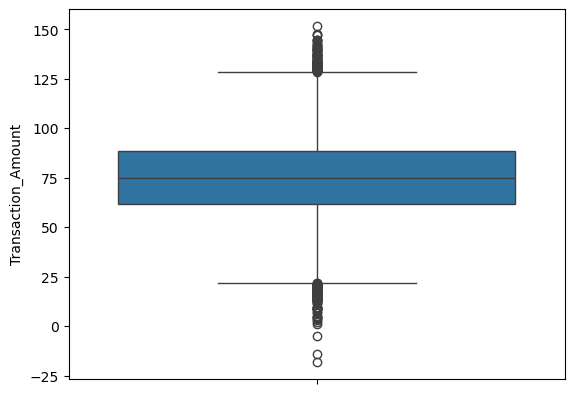

In [26]:
sns.boxplot(y=df['Transaction_Amount'])

Identify outliers using:  

IQR method

In [29]:
q1 = df['Transaction_Amount'].quantile(0.25)
q3 = df['Transaction_Amount'].quantile(0.75)
iqr = q3 - q1
lower_fence = q1-1.5*(iqr)
upper_fence = q3 +1.5*(iqr)

outliers = df[(df['Transaction_Amount' ]<lower_fence) | (df[ 'Transaction_Amount' ]>upper_fence)]
outliers

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
25,26,S002,20.09,2,Sun,41
77,78,S001,132.30,3,Thu,30
200,201,S002,18.94,6,Thu,36
417,418,S001,139.41,3,Fri,42
904,905,S001,133.01,4,Tue,31
...,...,...,...,...,...,...
24660,24661,S001,130.65,5,Tue,37
24746,24747,S003,14.83,8,Sat,22
24852,24853,S003,135.95,4,Thu,37
24854,24855,S003,7.35,6,Tue,56


Remove outliers and recompute:

Mean  
Median  

In [35]:
clean_df = df[(df['Transaction_Amount'] >= lower_fence) & (df['Transaction_Amount'] <= upper_fence)]

In [31]:
clean_df

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32
...,...,...,...,...,...,...
24995,24996,S004,102.24,6,Mon,45
24996,24997,S001,47.09,5,Mon,23
24997,24998,S003,72.37,5,Tue,38
24998,24999,S004,66.39,5,Thu,32


In [36]:
clean_df['Transaction_Amount'].mean()

np.float64(75.04479814478725)

In [37]:
clean_df['Transaction_Amount'].median()

75.07

Range=Max−Min

Q16

Find range of:

Transaction_Amount
Customer_Age

In [38]:
range_ta = df['Transaction_Amount']. max( ) - df['Transaction_Amount'].min( )
range_ta

169.83999999999997

In [39]:
range_ca = df['Customer_Age']. max( ) - df['Customer_Age'].min( )
range_ca

51

In [40]:
df.head()

,Customer_ID,Store_ID,Transaction_Amount,Basket_Size,Visit_Day,Customer_Age
0,1,S001,79.18,6,Thu,43
1,2,S004,76.53,5,Fri,48
2,3,S002,96.41,7,Sun,52
3,4,S001,97.63,4,Tue,61
4,5,S004,87.47,1,Wed,32


In [41]:
df.std(numeric_only=True)

Customer_ID           7217.022701
Transaction_Amount      19.977965
Basket_Size              2.249787
Customer_Age            15.064971
dtype: float64

In [45]:
df.select_dtypes(include='number').std()          #Alternate

Customer_ID           7217.022701
Transaction_Amount      19.977965
Basket_Size              2.249787
Customer_Age            15.064971
dtype: float64

Which variable is more spread out?

In [46]:
df.std(numeric_only=True).sort_values(ascending=False)

Customer_ID           7217.022701
Transaction_Amount      19.977965
Customer_Age            15.064971
Basket_Size              2.249787
dtype: float64

Why is range unreliable for this dataset?

**Range considers only max and min values. However, Std. Deviation considers distance of each value from the mean. Hence, Std. deviation is the better measure to find out
how reliable the dataset is.**

Concept: Spread using squared deviations (page 29)

Q19

Compute variance of:

Transaction_Amount
Customer_Age

In [47]:
df['Transaction_Amount'].var()

399.11906916949516

In [48]:
df['Customer_Age'].var()

226.95334488420193

Which feature is more volatile? (Less Reliable)

**Transaction Amount is the column which has greater variance which means it is more volatile.**

Compare std deviation across stores

In [51]:
df.groupby('Store_ID')['Transaction_Amount'].std().sort_values(ascending=False)

Store_ID
S002    20.292766
S004    19.940429
S001    19.894279
S003    19.777187
Name: Transaction_Amount, dtype: float64

Which is more robust to outliers? MAD vs. STD

CV=
μ/σ
	


Q27

Compute CV for:

Transaction_Amount

In [63]:
cv = df['Transaction_Amount'].mean() / df['Transaction_Amount'].std()
print(cv)

3.7551488521805045


COV for each store id

Histogram of Transaction_Amount

<Axes: xlabel='Transaction_Amount', ylabel='Count'>

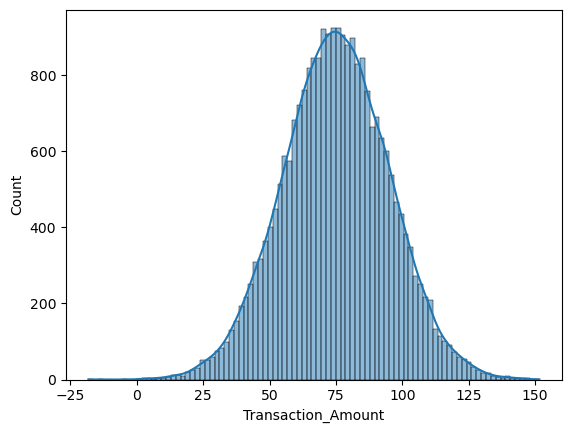

In [53]:
sns.histplot(df['Transaction_Amount'], kde=True)

***Bell-shaped graph/curve means Mean and Median are almost the same***

Boxplot of Transaction_Amount per Store

<Axes: xlabel='Store_ID', ylabel='Transaction_Amount'>

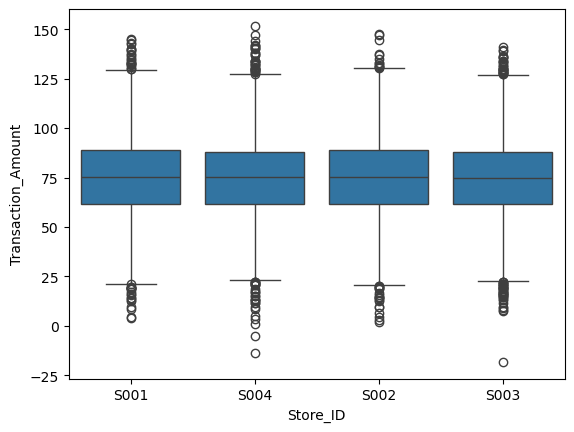

In [54]:
sns.boxplot(x='Store_ID', y='Transaction_Amount', data=df)

**S004 has more outliers.**

Should the company use:

Mean or Median to define "average customer spend"?

**Median is better.**

Which day has:

Highest spending customers?

In [57]:
df.groupby('Visit_Day')['Transaction_Amount'].sum().sort_values(ascending=False).head(1)

Visit_Day
Mon    276336.06
Name: Transaction_Amount, dtype: float64

Which store:

Has consistent customers (low variance)?

In [60]:
df.groupby('Store_ID')['Transaction_Amount'].var().sort_values().head(1)

Store_ID
S003    391.137114
Name: Transaction_Amount, dtype: float64